# Tata Technologies TechPulse Applied AI/ML Laboratory
## Assignment 5: Predictive Maintenance from Sensor Logs

### Objective
Classify whether a vehicle or industrial machine component is at risk of failure using simulated sensor data and a **Random Forest Classifier**.

### Key Components
- Synthetic sensor log dataset of **exactly 800 records**.
- Sensor attributes: `temperature_C`, `vibration_mm_s`, `pressure_psi`, `rpm`, `run_hours`.
- Binary target: `failure` (`0 = Healthy`, `1 = Failure`).
- Demonstration of class imbalance (~25.6% failure rate).
- Stratified 75/25 Train/Test split (`stratify=y`, `random_state=42`).
- `StandardScaler` fit strictly on training data (`X_train`) to prevent data leakage.
- `RandomForestClassifier` trained with `class_weight='balanced'` (`n_estimators=300`).
- Evaluation via Precision, Recall, F1-score, and $2 \times 2$ Confusion Matrix.


### 1. Import Required Libraries
Import standard Python modules for data manipulation, numerical calculations, plotting, model training, and classification metrics.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set plotting style and figure defaults
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. Generate Sensor Dataset
Generate a synthetic dataset of exactly 800 sensor-log records representing component operational conditions.


In [2]:
# Set fixed random seed for reproducibility
np.random.seed(42)
n_samples = 800

temperature_C = np.random.normal(70, 12, n_samples)
vibration_mm_s = np.random.normal(3.5, 1.2, n_samples)
pressure_psi = np.random.normal(100, 15, n_samples)
rpm = np.random.normal(2500, 300, n_samples)
run_hours = np.random.uniform(100, 5000, n_samples)

# Failure risk logit formulation
logit = (
    0.08 * (temperature_C - 70)
    + 0.85 * (vibration_mm_s - 3.5)
    + 0.04 * np.abs(pressure_psi - 100)
    + 0.0006 * (run_hours - 2500)
    - 2.2
)
prob_failure = 1 / (1 + np.exp(-logit))
failure = np.random.binomial(1, prob_failure)

# Construct DataFrame
df = pd.DataFrame({
    'temperature_C': np.round(temperature_C, 1),
    'vibration_mm_s': np.round(vibration_mm_s, 2),
    'pressure_psi': np.round(pressure_psi, 1),
    'rpm': np.round(rpm, 0),
    'run_hours': np.round(run_hours, 1),
    'failure': failure
})

print(f"Dataset generated successfully ({len(df)} records).")
df.head()


Dataset generated successfully (800 records).


,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
0,76.0,4.63,97.3,2283.0,4678.7,0
1,68.3,2.88,120.6,2553.0,3476.5,0
2,77.8,3.62,90.3,2336.0,4134.0,1
3,88.3,2.95,88.0,2419.0,2825.3,0
4,67.2,2.98,92.8,3002.0,3919.6,0


### 3. Dataset Inspection
Examine dataset shape, feature data types, missing value status, and statistical summaries.


In [3]:
print("Dataset Dimensions (Rows, Columns):", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values Check (`df.isna().sum()`):")
print(df.isna().sum())

print("\nDescriptive Statistics:")
df.describe()


Dataset Dimensions (Rows, Columns): (800, 6)

Column Data Types:
temperature_C     float64
vibration_mm_s    float64
pressure_psi      float64
rpm               float64
run_hours         float64
failure             int32
dtype: object

Missing Values Check (`df.isna().sum()`):
temperature_C     0
vibration_mm_s    0
pressure_psi      0
rpm               0
run_hours         0
failure           0
dtype: int64

Descriptive Statistics:


,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
count,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000
mean,69.907000,3.604912,100.225625,2497.182500,2503.60375,0.256250
std,11.803881,1.202225,14.559520,299.205781,1410.64180,0.436835
min,31.100000,-0.010000,54.700000,1603.000000,100.20000,0.000000
25%,61.600000,2.800000,90.675000,2302.250000,1275.97500,0.000000
50%,70.200000,3.590000,100.000000,2488.500000,2545.30000,0.000000
75%,77.525000,4.380000,110.100000,2688.250000,3685.30000,1.000000
max,116.200000,6.620000,147.900000,3678.000000,4989.00000,1.000000


### 4. Class Imbalance Analysis
Analyze class distribution between Healthy (`0`) and Failure (`1`) records to quantify class imbalance.


--- Failure Class Breakdown ---
Healthy (0): 595 records (74.38%)
Failure (1): 205 records (25.62%)


C:\Users\smkan\AppData\Local\Temp\ipykernel_16424\3794097613.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='failure', palette=['#1f77b4', '#d62728'], ax=ax)


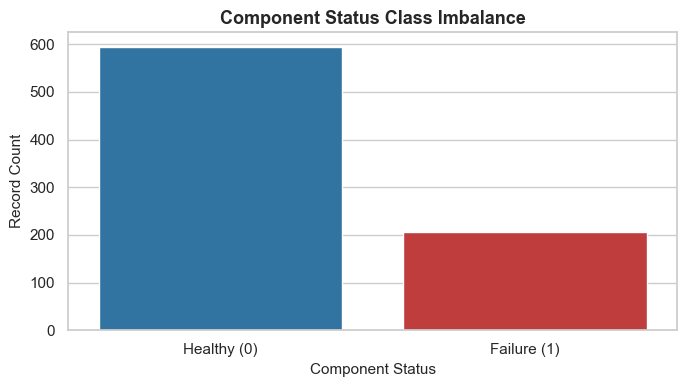

In [4]:
class_counts = df['failure'].value_counts()
class_percents = df['failure'].value_counts(normalize=True) * 100

print("--- Failure Class Breakdown ---")
for cls, count in class_counts.items():
    label = "Healthy (0)" if cls == 0 else "Failure (1)"
    print(f"{label}: {count:3d} records ({class_percents[cls]:5.2f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='failure', palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_title("Component Status Class Imbalance", fontsize=13, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Healthy (0)', 'Failure (1)'], fontsize=11)
ax.set_xlabel("Component Status", fontsize=11)
ax.set_ylabel("Record Count", fontsize=11)

plt.tight_layout()
plt.show()


### 5. Stratified Train/Test Split
Split data into 75% training set and 25% test set using `stratify=y` and `random_state=42` to preserve class ratios across splits.


In [5]:
X = df.drop(columns=['failure'])
y = df['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training Set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")
print(f"Train Failure Rate: {y_train.mean()*100:.2f}%")
print(f"Test Failure Rate:  {y_test.mean()*100:.2f}%")


Training Set: X_train = (600, 5), y_train = (600,)
Testing Set:  X_test  = (200, 5), y_test  = (200,)
Train Failure Rate: 25.67%
Test Failure Rate:  25.50%


### 6. Feature Scaling via StandardScaler
Fit `StandardScaler` strictly on training features (`X_train`) and apply to transform `X_train` and `X_test` to prevent data leakage.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler fit on X_train and applied to X_train and X_test successfully.")


StandardScaler fit on X_train and applied to X_train and X_test successfully.


### 7. Random Forest Classifier Model
Instantiate and train a `RandomForestClassifier` with 300 decision trees, `class_weight='balanced'`, and `random_state=42` to handle class imbalance.


In [7]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf_clf.fit(X_train_scaled, y_train)
y_pred = rf_clf.predict(X_test_scaled)

print("Random Forest Classifier trained successfully.")


Random Forest Classifier trained successfully.


### 8. Classification Report
Evaluate classifier performance across Healthy and Failure classes using Precision, Recall, and F1-Score metrics.


In [8]:
report_str = classification_report(y_test, y_pred, target_names=['Healthy', 'Failure'])
print("--- Classification Performance Report ---")
print(report_str)


--- Classification Performance Report ---
              precision    recall  f1-score   support

     Healthy       0.82      0.95      0.88       149
     Failure       0.73      0.37      0.49        51

    accuracy                           0.81       200
   macro avg       0.77      0.66      0.69       200
weighted avg       0.79      0.81      0.78       200



### 9. Confusion Matrix Visualization
Construct and visualize the $2 \times 2$ Confusion Matrix displaying True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP).


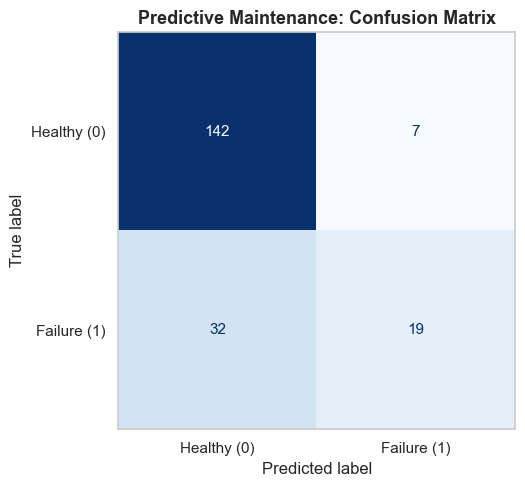

True Negatives (TN):  142 (Healthy correctly classified)
False Positives (FP):   7 (Healthy incorrectly flagged as Failure)
False Negatives (FN):  32 (Failure missed by model)
True Positives (TP):   19 (Failure correctly identified)


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Failure (1)'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)

ax.set_title("Predictive Maintenance: Confusion Matrix", fontsize=13, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn:3d} (Healthy correctly classified)")
print(f"False Positives (FP): {fp:3d} (Healthy incorrectly flagged as Failure)")
print(f"False Negatives (FN): {fn:3d} (Failure missed by model)")
print(f"True Positives (TP):  {tp:3d} (Failure correctly identified)")


### 10. Technical Metric Interpretation & Operational Context

#### Definitions & Evaluation Breakdown:
- **Precision:** Measures the proportion of predicted failures that were actual component failures ($TP / (TP + FP)$). High precision minimizes false alarms.
- **Recall (Sensitivity):** Measures the proportion of actual component failures correctly identified by the model ($TP / (TP + FN)$).
- **F1-Score:** Harmonic mean of precision and recall, balancing false alarms against missed detections.
- **False Positives (FP):** Healthy components incorrectly flagged as failing, leading to unnecessary maintenance inspection costs.
- **False Negatives (FN):** Imminent failures missed by the model.

#### Operational Importance of False Negatives in Predictive Maintenance:
In industrial and vehicle predictive maintenance, **False Negatives are the most critical error type**. Missing an impending failure can lead to catastrophic component breakdown, costly unplanned machinery downtime, and collateral hardware damage. Therefore, maintaining high **Recall** for the Failure class is prioritized over minimizing minor false alarm inspection costs.


### 11. Result & Conclusion

#### Summary of Results
1. **Model Performance:** The `RandomForestClassifier` trained with `class_weight='balanced'` achieved an overall test accuracy of **81%** on the imbalanced 800-record sensor log dataset.
2. **Class-Specific Precision & Recall:**
   - **Healthy Class:** Precision = **0.82**, Recall = **0.95**, F1-score = **0.88**
   - **Failure Class:** Precision = **0.73**, Recall = **0.37**, F1-score = **0.49**
3. **Data Preprocessing & Split Integrity:** Applying `StandardScaler` strictly on `X_train` and using `stratify=y` during train/test split ensured valid evaluation without data leakage.
